<a href="https://colab.research.google.com/github/Chichat1/residencia_anest/blob/main/projeto_res__anest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CARREGANDO BIBLIOTECAS

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime
import numpy as np
import re

print('Bibliotecas carregadas✅')

Bibliotecas carregadas✅


# IMPORTANDO DADOS

In [2]:
planilha_id = "1je1OgJ1iS6yDheMLo5b051WYfamh6DRojbjpQ7AlA1c"
url = f"https://docs.google.com/spreadsheets/d/1je1OgJ1iS6yDheMLo5b051WYfamh6DRojbjpQ7AlA1c/export?format=csv"
df = pd.read_csv(url)
try:
  from google.colab import drive
  drive.mount('/content/drive')
  pasta_projeto = '/content/drive/MyDrive/Residência'
  print("✅ Rodando no ambiente do hospital (Google Colab)")

except ModuleNotFoundError:
    pasta_projeto = './'
    print("💻 Rodando em casa (VS Code Local)")

Mounted at /content/drive
✅ Rodando no ambiente do hospital (Google Colab)


In [3]:
pd.set_option('display.max_columns', None)
df.drop(columns=['Carimbo de data/hora', 'alta_medica'], inplace=True)
df.head(5)

,data_procedimento,apelido_paciente,id_prontuario,especie,raca,sexo,peso_kg,idade,alergias_anteriores,doencas_anteriores,cirurgias_anteriores,cardiorrespiratorio,digestorio,neurologico,locomotor,endocrino_hematologico,genitourinario,ASA,mpa,inducao,manutencao,local_anest,outros_farmacos,procedimento,procedimento_sedacao,procedimento_ciru,anestesistas,cirurgioes,intubacao,intercorrencias_trans_anest,inicio_anest,inicio_ciru,fim_anest,fc_momentos,fr_momentos,spO2_momentos,pas_momentos,recuperação_anest,fim_ciru,temp_momentos,etco2_momentos,perda_volemica,decubito_trans,drogas_emergencia
0,06/03/2026,Bella,73904,canina,srd,fêmea,10.4,12a,não,cisto esplênico,esplenectomia,cansaço,NaN,NaN,NaN,sangramentos,alterações_uterinas,ASA II,"metadona (0.30), dexmedetomidina (1)","propofol (3), fentanil (2), lidocaína (1)","iso, flk",lidocaína (2),dipirona (2.5),complexo,NaN,oh,"samuel, hallana, mateus","isabela, camila",8,NaN,09:26:00,10:40:00,10:42:00,"85, 120, 148, 117, 93, 93","12, 20, 20, 12, 16, 20","99, 98, 97, 98, 98, 98","80, 74, 130, 120, 94, 86",9.0,NaN,NaN,NaN,NaN,NaN,NaN
1,23/03/2026,Malevola,74085,felina,srd,fêmea,2.6,3a,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ASA II,NaN,"propofol, fentanil",NaN,NaN,NaN,simples,sondagem orogástrica,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,23/03/2026,Poyo,74069,felina,srd,macho,3.2,5a,não,tríade felina,orquiectomia,NaN,"êmese, anorexia",NaN,NaN,NaN,NaN,ASA III,NaN,propofol (15),NaN,NaN,NaN,simples,sondagem orogástrica,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,06/03/2026,Fumaça,73990,felina,srd,macho,4.0,1a,não,não,não,edema,diarréia,NaN,"claudicação, traumas",anemia,NaN,ASA II,"metadona (0.3), dexmedetomidina (4)","propofol (3), cetamina (2), fentanil (2)","iso, fk",ropivacaína (1),dipirona (12.5),complexo,NaN,osteossíntese de olécrano,"samuel, hallana, mateus","andré, caio",3,resgate analgésico,13:45:00,14:58:00,16:19:00,"112, 104, 120, 236, 218, 168, 216, 144","20, 12, 20, 36, 28, 28, 33","98, 97, 98, 98, 99, 99 100, 98, 98","130, 140, 160, 203, 210, 215, 198, 180",9.0,16:10:00,NaN,NaN,NaN,NaN,NaN
4,10/03/2026,Hope,73901,canina,pitbull,fêmea,30.0,5a,não,não,osh,NaN,NaN,NaN,claudicação,NaN,NaN,ASA II,metadona (0.3),"fentanil (2), propofol (4), quetamina (1)",NaN,NaN,NaN,simples,rx mpe tplo,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# CORREÇÃO DE DTYPES

In [ ]:
## Coluna de < DATA >
df['data_procedimento'] = pd.to_datetime(df['data_procedimento'], dayfirst=True, errors='coerce')
## Coluna de < ID >
df['id_protuario'] = df['id_prontuario'].astype(str)
## Coluna de < PESO >
df['peso_kg'] = pd.to_numeric(df['peso_kg'], errors='coerce')
## Colunas de < HORÁRIO >
colunas_horario = ['inicio_anest', 'inicio_ciru', 'fim_anest', 'fim_ciru']
for col in colunas_horario:
  df[col] = pd.to_datetime(df[col], format='%H:%M:%S', errors='coerce').dt.time
## Colunas de < IDADE >
def converter_idade(idade_str):
  if pd.isna(idade_str):
    return np.nan
    idade_str = str(idade_str).lower().replace(' ', '')

    match = re.search(r'\d+', idade_str)
    if not match:
        return np.nan

    numero = float(match.group())

    # Se tiver 'm' (meses), divide por 12
    if 'm' in idade_str:
        return round(numero / 12, 2)
    return numero

df['idade_anos'] = df['idade'].apply(converter_idade)
df.drop(columns=['idade'], inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 45 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   data_procedimento            90 non-null     datetime64[ns]
 1   apelido_paciente             90 non-null     object        
 2   id_prontuario                90 non-null     int64         
 3   especie                      90 non-null     object        
 4   raca                         85 non-null     object        
 5   sexo                         90 non-null     object        
 6   peso_kg                      90 non-null     float64       
 7   alergias_anteriores          85 non-null     object        
 8   doencas_anteriores           84 non-null     object        
 9   cirurgias_anteriores         86 non-null     object        
 10  cardiorrespiratorio          25 non-null     object        
 11  digestorio                   34 non-null     ob

# Quantidade de procedimentos mensais

In [ ]:
total_procedimentos = df.shape[0]
print(f'Total de procedimentos realizados: {total_procedimentos}')
df['mes_ano'] = df['data_procedimento'].dt.to_period('M')
procedimentos_mensais = df['mes_ano'].value_counts().sort_index().to_frame(name='Quantidade de procedimentos mensais')
display(procedimentos_mensais)

Total de procedimentos realizados: 90


,Quantidade de procedimentos mensais
mes_ano,
2026-03,39
2026-04,42
2026-05,9


# Prevalência de sexo

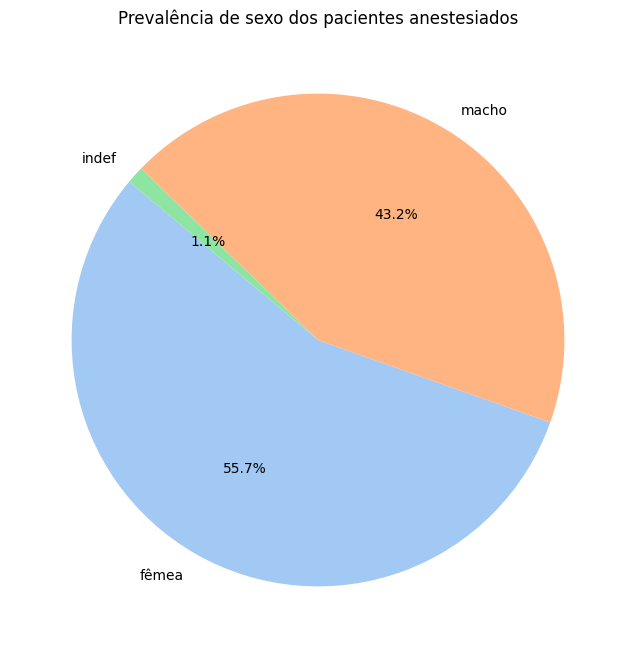

,Quantidade
sexo,
fêmea,49
macho,38
indef,1


In [ ]:
# Contagem da prevalência por sexo dos animais anestesiados
sexo_counts = df['sexo'].value_counts()

# Plotando o gráfico de pizza
plt.figure(figsize=(10, 8))
plt.pie(sexo_counts, labels=sexo_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Prevalência de sexo dos pacientes anestesiados')
plt.show()

# Valores absolutos
display(sexo_counts.to_frame(name='Quantidade'))

# Prevalência de raças e espécies



## Raças

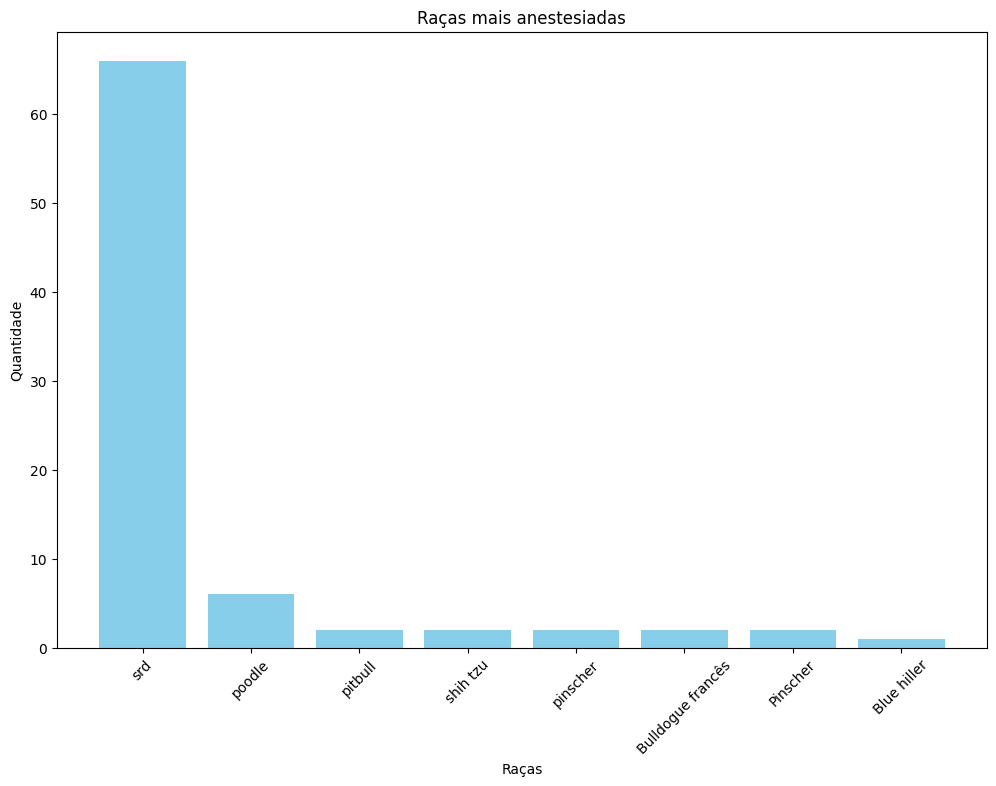

,Raças mais anstesiadas
raca,
srd,66
poodle,6
pitbull,2
shih tzu,2
pinscher,2
Bulldogue francês,2
Pinscher,2
Blue hiller,1


In [ ]:
# Prevalência das raças mais anestesiadas
raca_counts = df['raca'].value_counts()

# Plot de raças mais anestesiadas
plt.figure(figsize=(12, 8))
plt.bar(raca_counts.index, raca_counts.values, color='skyblue')
plt.xlabel('Raças')
plt.ylabel('Quantidade')
plt.title('Raças mais anestesiadas')
plt.xticks(rotation=45)
plt.show()

# Valores absolutos de raça
display(raca_counts.to_frame(name='Raças mais anstesiadas'))

## Espécies

In [ ]:
especie_counts = df['especie'].value_counts()
display(especie_counts.to_frame(name='Diferentes espécies atendidas'))

,Diferentes espécies atendidas
especie,
canina,43
felina,41
cerdocyon thous,1
chelonoidis carbonarius,1
amazona amazonica,1
cerdoncyon thous,1


# Prevalência de classificações ASA

In [ ]:
asa_counts = df['ASA'].value_counts()
display(asa_counts.to_frame(name='Classificação ASA dos pacientes atendidos'))

,Classificação ASA dos pacientes atendidos
ASA,
ASA II,69
ASA III,14
ASA I,4
ASA IV,1


# Tipos de procedimentos realizados

In [ ]:
tipos_procedimentos = df['procedimento'].value_counts()
display(tipos_procedimentos.to_frame(name='Quantidades de procedimentos por tipo'))

,Quantidades de procedimentos por tipo
procedimento,
complexo,59
simples,29


## Procdimentos cirúrgicos mais comuns🔪

In [ ]:
procedimentos_complexos = df['procedimento_ciru'].value_counts()
display(procedimentos_complexos.to_frame(name='Quantidade de procedimentos complexos'))

,Quantidade de procedimentos complexos
procedimento_ciru,
osh terapêutica,14
oh terapêutica,4
colocefalectomia,2
mastectomia unilateral,2
laparatomia exploratória,2
oh,1
osteossíntese de olécrano,1
"ablação de conduto auditivo, conchectomia",1
enucleação unilateral,1


## Procedimentos de sedações mais comuns💉

In [ ]:
procedimentos_simples = df['procedimento_sedacao'].value_counts()
display(procedimentos_simples.to_frame(name='Procedimentos de sedações'))

,Procedimentos de sedações
procedimento_sedacao,
desobstrução uretral,6
rx crânio,4
sondagem orogástrica,2
rx mpe tplo,1
troca de curativo,1
remoção corpo estranho cervical,1
reposicionamento de prolapso retal,1
rx femorotibiopatelar,1
rx pelve e escapulo umeral,1


# Duração dos procedimentos

## Duração média das cirurgias

## Duração média das anestesias

# Afecções por sistema